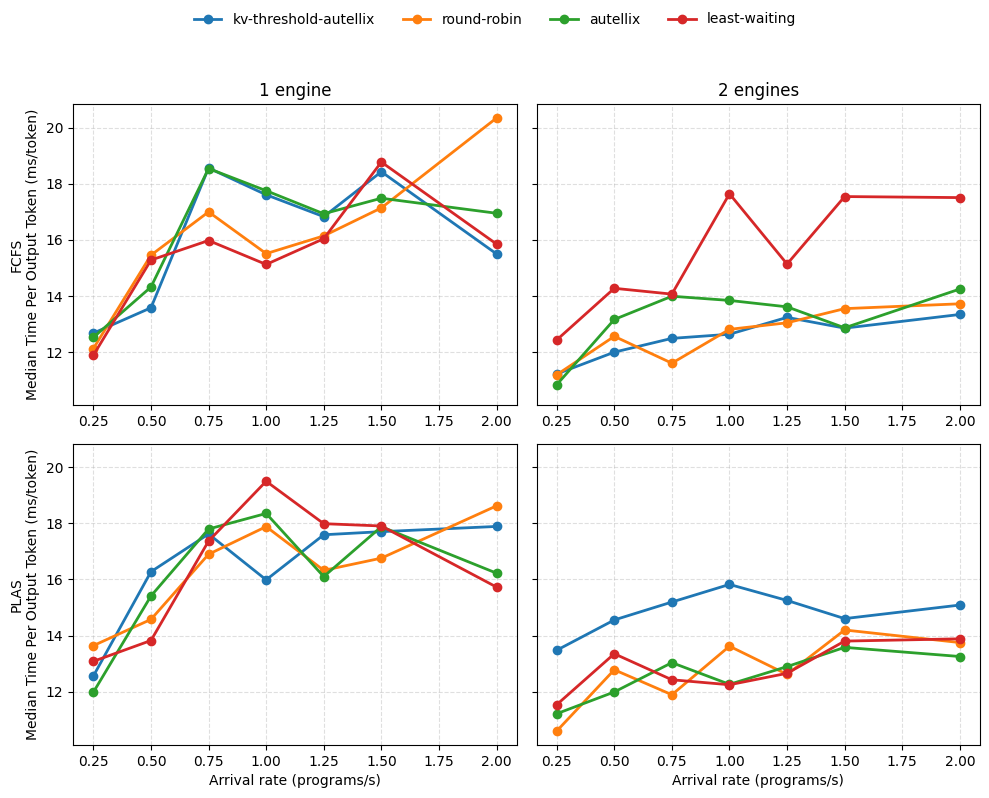

In [8]:
import json
import glob
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================
OUTPUT_DIRS = {
    "1 engine": "outputs_benchmark_load_balancer",
    "2 engines": "outputs_benchmark_load_balancer_2_engines",
    # "4 engines": "outputs_4_engines",
}

SCHEDULERS = ["fcfs", "plas"]
Y_METRIC = "median_tpot_ms"

# Optional: fixed colors for consistency
COLORS = {
    "round-robin": "#1f77b4",
    "least-waiting": "#ff7f0e",
    "autellix": "#2ca02c",
    "kv-threshold-autellix": "#d62728",
}

# results[engine][scheduler][strategy][rate] = [values]
results = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
)

pattern = re.compile(
    r"output_([^_]+)_([^_]+)_rate([\d.]+)_run\d+\.json"
)


# ============================================================
# LOAD DATA
# ============================================================
for engine_label, folder in OUTPUT_DIRS.items():
    for path in glob.glob(f"{folder}/*.json"):
        filename = path.split("/")[-1]
        match = pattern.match(filename)
        if not match:
            continue

        scheduler = match.group(1)
        strategy = match.group(2)
        rate = float(match.group(3))

        with open(path) as f:
            data = json.load(f)

        value = data["full_metrics"][Y_METRIC]
        results[engine_label][scheduler][strategy][rate].append(value)

# ============================================================
# PLOTTING
# ============================================================
n_rows = len(SCHEDULERS)
n_cols = len(OUTPUT_DIRS)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=True
)

# ✅ CORRECT normalization
if n_cols == 1:
    axes = axes.reshape(n_rows, 1)
elif n_rows == 1:
    axes = axes.reshape(1, n_cols)

for col, (engine_label, _) in enumerate(OUTPUT_DIRS.items()):
    for row, scheduler in enumerate(SCHEDULERS):
        ax = axes[row, col]

        for strategy, rate_dict in results[engine_label][scheduler].items():
            rates = sorted(rate_dict.keys())
            values = [
                sum(rate_dict[r]) / len(rate_dict[r]) for r in rates
            ]

            ax.plot(
                rates,
                values,
                marker="o",
                linewidth=2,
                label=strategy
            )

        if row == 0:
            ax.set_title(engine_label)

        if col == 0:
            ax.set_ylabel(f"{scheduler.upper()}\nMedian Time Per Output Token (ms/token)")

        if row == n_rows - 1:
            ax.set_xlabel("Arrival rate (programs/s)")

        ax.grid(True, linestyle="--", alpha=0.4)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
